In [146]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path
from scipy.stats import friedmanchisquare, kruskal, median_abs_deviation, wilcoxon
from statsmodels.stats.multitest import multipletests
from math import ceil

In [189]:
outliermeth = 'iqr_outlier'
outliertreatment = 'impute'
normtype = 'zscore'

base_dir = Path().resolve()
folderpath = os.path.join(base_dir, "..","Biometrics", "Outputs", f'outlier_{outliertreatment}', outliermeth)
folderpath = os.path.abspath(folderpath)
folderpath


'C:\\Users\\josee\\OneDrive\\Documentos\\GitHub\\neurohumanities-lab\\OfflineProcessing\\Biometrics\\Outputs\\outlier_impute\\iqr_outlier'

In [190]:
def remove_outliers_winsor(col, p_low=0.05, p_high=0.95):
    lower = col.quantile(p_low)
    upper = col.quantile(p_high)
    return col.clip(lower=lower, upper=upper)

def remove_outliers_iqr(col, treatment='elim'):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    if treatment == 'impute':
        return col.clip(lower=lower, upper=upper)
    else:
        return col[(col >= lower) & (col <= upper)]

scenedata = {}
non_norm_data = {0:pd.read_csv(os.path.join(folderpath,'non-normalized','biometric_feat_mat_scene_0_nonnorm.csv'))}
for scene in range(1,5):
    dataholder = pd.read_csv(os.path.join(folderpath,f"biometric_feat_mat_scene_{scene}_{normtype}.csv"))
    # dataholder.iloc[:, 1:] = dataholder.iloc[:, 1:].apply(
    #     remove_outliers_iqr,
    #     args=('impute',)
    # )
    # dataholder.iloc[:, 1:] = dataholder.iloc[:, 1:].apply(
    #     remove_outliers_winsor, args=(0.10, 0.9,)
    # )
    scenedata_nonnorm = pd.read_csv(os.path.join(folderpath,'non-normalized',rf'biometric_feat_mat_scene_{scene}_nonnorm.csv'))
    non_norm_data.update({scene:scenedata_nonnorm})
    scenedata.update({scene:dataholder})

In [191]:
# scenedata[4]

In [192]:
# non_norm_data[0]

In [193]:
outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", f'outlier_{outliertreatment}', outliermeth, normtype)
outpath = os.path.abspath(outpath)


# def plot_bars(data, scene=int, normtype=str, savecond=False, savepath=str, showfig=True):
#     means = data.mean()
#     plt.figure(figsize=(10, 6))
#     plt.bar(means.index, means.values, color='#1f77b4', edgecolor='black')
#     plt.title(f'Media de características escena {scene} - Normalización {normtype}')
#     plt.ylabel('Valor medio')
#     plt.xticks(rotation=45, ha='right')
#     plt.grid(axis='y', linestyle='--', alpha=0.7)
#     plt.tight_layout()
#     if savecond:
#         plt.savefig(os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'), dpi=300, bbox_inches='tight')
#     if showfig:
#         plt.show()
#     else:
#         plt.close()

In [194]:
def plot_bars(data, scene, normtype, savecond=False, savepath=None, showfig=True):
    """
    Plotea barras de la media de 'data' con barras de error de desviación estándar.
    """
    # calcular media y desviación estándar
    means = data.mean()
    stds = np.array(data.std().values)
    print(data.shape[0])
    errors = [stds / np.sqrt(data.shape[0]), stds / np.sqrt(data.shape[0])]

    plt.figure(figsize=(10, 6))
    # plot de barras con error bars
    plt.bar(
        means.index,
        means.values,
        yerr=errors,
        capsize=5,
        edgecolor='black'
    )
    plt.title(f'Media de características escena {scene} - Normalización {normtype}')
    plt.ylabel('Valor medio')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

    if savecond:
        plt.savefig(
            os.path.join(savepath, f'bar_scene{scene}_{normtype}.png'),
            dpi=300,
            bbox_inches='tight'
        )
    if showfig:
        plt.show()
    else:
        plt.close()

In [195]:
def compare_baseline_scene(baseline_df,scene_df, scene_num,savepath,show=True,save=True):
    features = baseline_df.columns
    n_features = len(features)
    
    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        base_vals = baseline_df[feature].dropna()
        scene_vals = scene_df[feature].dropna()
        
        means = [base_vals.mean(), scene_vals.mean()]
        errors = [base_vals.std() / np.sqrt(len(base_vals)), scene_vals.std() / np.sqrt(len(scene_vals))]

        
        ax.bar([0, 1], means, yerr=errors, capsize=5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Baseline', f'Scene {scene_num}'])
        ax.set_title(feature)
    
    for j in range(n_features, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle(f'Comparison of Scene {scene_num} and baseline accross all features')
    plt.tight_layout()
    
    if save:
        plt.savefig(
            os.path.join(savepath, f'baseline_scene{scene_num}_comparison.png'),
            dpi=300,
            bbox_inches='tight'
        )
    
    if show:
        plt.show()
    
    plt.close(fig)



45


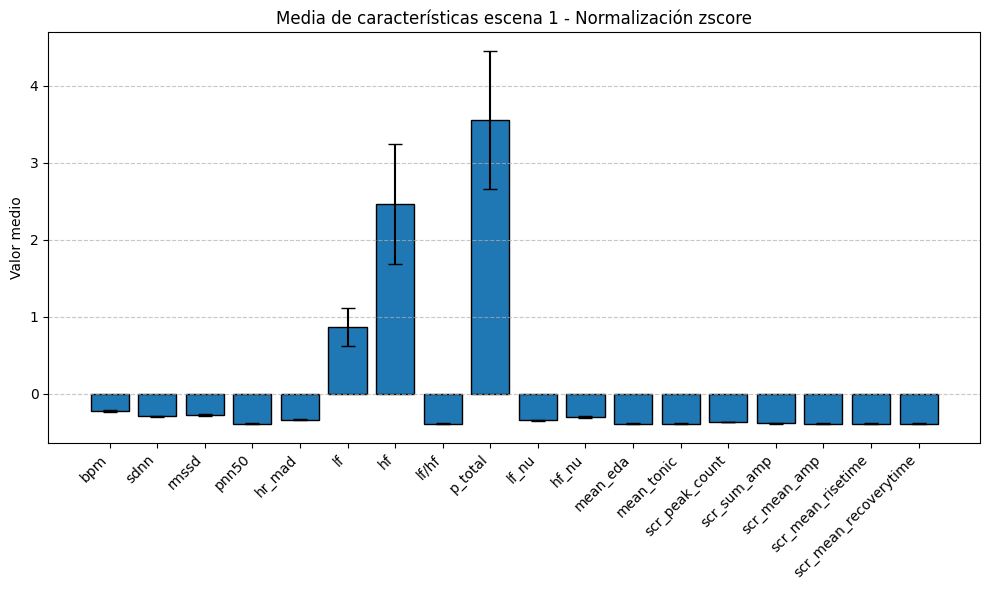

42


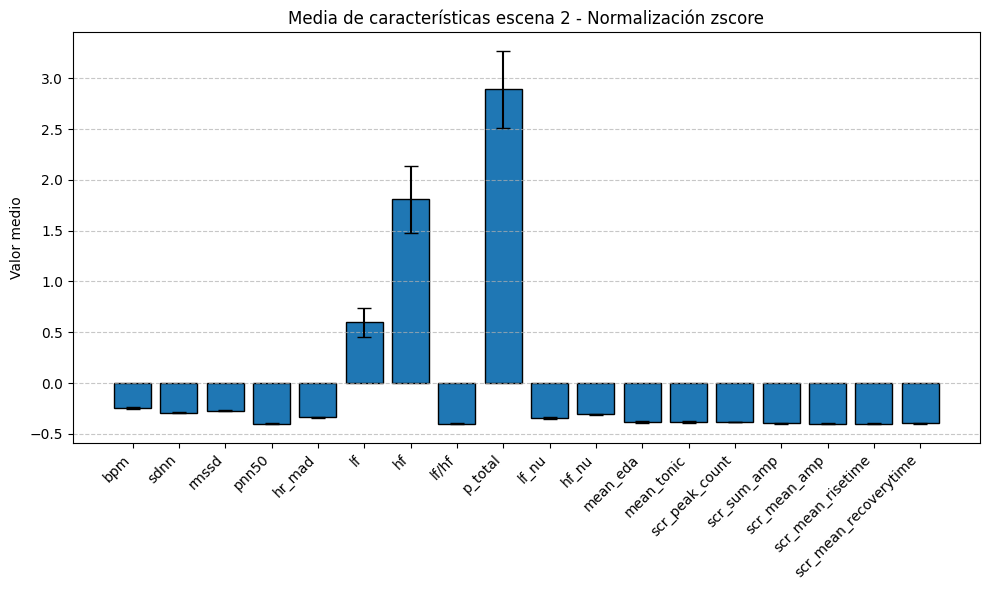

42


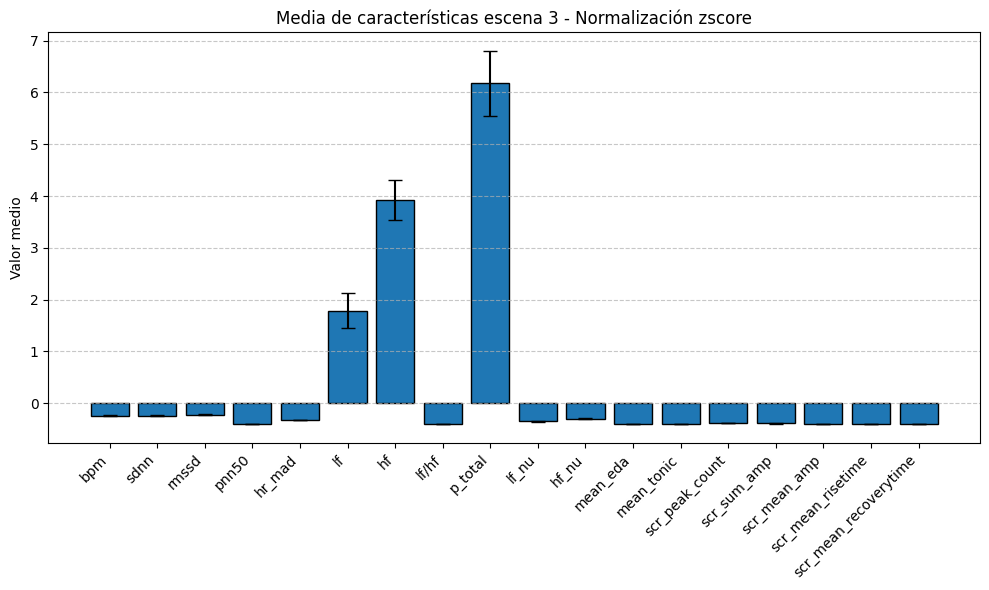

47


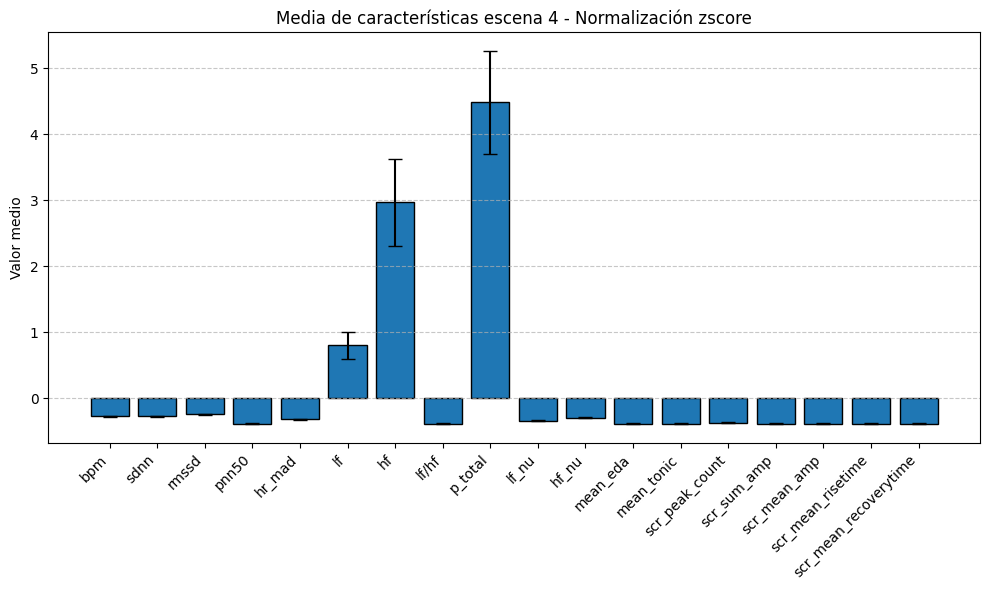

In [196]:
for probe in range(1, 5):
    plot_bars(
        scenedata[probe].drop("Subject", axis=1),
        probe,
        normtype,
        savecond=True,
        savepath=outpath,
        showfig=True,
    )


nonnorm_outpath = os.path.join(base_dir, "..","Biometrics", "Outputs", "Figures", f'outlier_{outliertreatment}', outliermeth, 'non_norm')
for probe in range(1, 5):
    compare_baseline_scene(
        non_norm_data[0].drop("Subject", axis=1),
        non_norm_data[probe].drop("Subject", axis=1),
        scene_num=probe,
        show=False,
        save=False,
        savepath=os.path.join(nonnorm_outpath),
    )

In [197]:
non_norm_data[3].drop('Subject', axis=1).dropna()

,bpm,sdnn,rmssd,pnn50,hr_mad,lf,hf,lf/hf,p_total,lf_nu,hf_nu,mean_eda,mean_tonic,scr_peak_count,scr_sum_amp,scr_mean_amp,scr_mean_risetime,scr_mean_recoverytime
0,155.781455,132.219350,149.818175,0.303797,80.46875,1296.090196,2059.325665,0.629376,3355.415861,38.626813,61.373187,0.009317,0.009089,20.0,0.303490,0.017828,0.650000,0.982143
1,155.781455,117.753425,163.549030,0.292683,78.12500,665.331751,1607.125991,0.413989,2291.540046,29.278069,70.721931,0.003045,0.003111,24.6,0.303476,0.017828,0.572788,0.773333
2,155.781455,96.986942,118.198472,0.258427,62.50000,384.298650,2356.942880,0.134302,2471.269967,11.818972,88.181028,0.004435,0.004640,16.0,0.303476,0.018965,0.572788,0.773333
3,152.102377,151.589901,139.412634,0.296875,80.46875,985.405568,4644.389513,0.212171,5629.795081,17.503400,82.496600,0.026684,0.026693,6.7,0.303476,0.041192,0.650000,2.550000
4,91.596330,117.800725,146.432282,0.218750,31.25000,757.549784,3482.011957,0.217561,4239.561741,17.868587,82.131413,-0.007472,-0.006858,9.0,0.306149,0.034017,1.222222,2.550000
5,92.530120,129.083685,175.847800,0.245283,39.06250,384.298650,2727.169537,0.134302,3020.852370,11.818972,88.181028,-0.007493,-0.007410,10.0,0.480404,0.048040,1.475000,2.305556
6,103.572519,153.358264,175.847800,0.250000,62.50000,550.521600,5334.521355,0.134302,5885.042955,11.818972,88.181028,-0.003431,-0.004394,24.6,0.342504,0.017828,0.572788,0.773333
7,100.702622,153.358264,175.847800,0.211538,46.87500,1723.003999,5999.462752,0.287193,7722.466751,22.311575,77.688425,-0.023351,-0.023370,20.0,0.437738,0.021887,0.587500,0.783333
8,109.990557,121.862416,115.772710,0.133297,62.50000,3340.782521,6170.936922,0.508410,9911.825839,33.705016,66.294984,-0.021928,-0.018657,6.7,1.344445,0.224074,1.458333,2.550000
9,110.678383,112.241643,115.461179,0.135802,39.06250,1646.535178,4537.992536,0.362833,6184.527714,26.623459,73.376541,-0.013049,-0.012558,15.0,0.420786,0.028052,0.950000,1.318182


In [198]:
def wilcoxon_paired(baseline_df, scene_df, alpha=0.05):
    features = baseline_df.columns

    baseline_no_na = baseline_df.dropna()
    scene_no_na = scene_df.dropna()
    n = min(len(baseline_no_na), len(scene_no_na))

    p_raw = []
    stats = []

    for feat in features:
        stat, p = wilcoxon(
            baseline_no_na[feat][0:n],
            scene_no_na[feat][0:n],
            zero_method='wilcox', 
            alternative='two-sided'
        )
        stats.append(stat)
        p_raw.append(p)

    reject, p_holm, _, _ = multipletests(p_raw, alpha=alpha, method='holm')

    results = pd.DataFrame({
        'feature': features,
        'statistic': stats,
        'p_raw': p_raw,
        'p_holm': p_holm,
        'reject_H0': reject
    })

    return results

multitests = []
for probe in range(1,5):
    re = wilcoxon_paired(non_norm_data[0].drop('Subject',axis=1), non_norm_data[probe].drop('Subject',axis=1))
    # re.to_csv(os.path.join(nonnorm_outpath,f'wilcoxon_multitest_baseline_scene{probe}.csv'))
    multitests.append(re)

c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\josee\OneDrive\Documentos\GitHub\neurohumanities-lab\.venv\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: Exact p-value calculation does not work if

In [199]:
multitests[0][multitests[0]['feature'] == 'bpm']

,feature,statistic,p_raw,p_holm,reject_H0
0,bpm,55.0,0.000381,0.006865,True


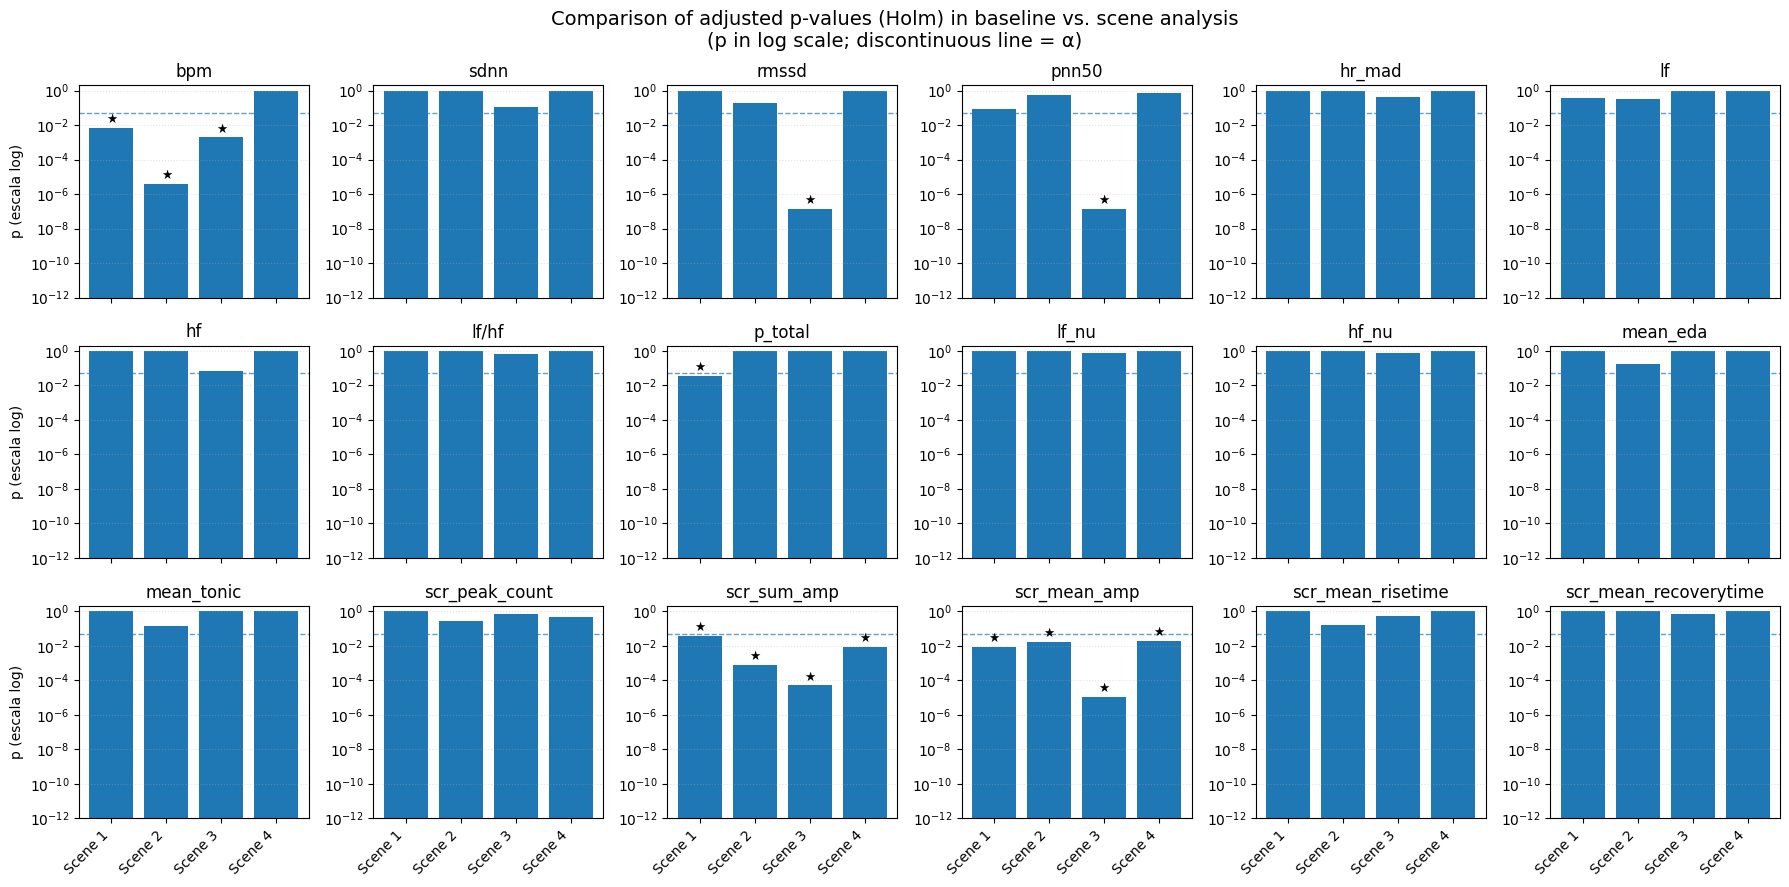

In [200]:
from matplotlib.ticker import LogLocator, LogFormatterSciNotation

def compare_pvalues(df_list, savepath, show=True, save=True, alpha=0.05, eps=1e-12):
    features = list(df_list[0]["feature"])
    n_features = len(features)
    n_scenes = len(df_list)

    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(n_scenes))
    x_labels = [f"Scene {i+1}" for i in range(n_scenes)]

    for idx, feature in enumerate(features):
        ax = axes[idx]

        p_values = []
        for sdf in df_list:
            m = sdf.loc[sdf["feature"] == feature, "p_holm"]
            pv = float(m.iloc[0]) if len(m) else np.nan
            p_values.append(pv)

        plot_vals = [max(p, eps) if np.isfinite(p) else np.nan for p in p_values]

        ax.bar(x_positions, plot_vals)
        if idx // ncols == nrows - 1: 
            ax.set_xticks(x_positions)
            ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
            ax.set_xticklabels([])

        # --- Escala log para p ---
        ax.set_yscale('log')
        ax.set_ylim(eps, 2)
        if idx % ncols == 0: 
            ax.set_ylabel("p (escala log)")
        else:
            ax.set_ylabel("")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(LogFormatterSciNotation())

        # Línea de significancia
        ax.axhline(alpha, linestyle="--", linewidth=1, alpha=0.7)

        # Marca estrella si p < alpha
        for x, pv in zip(x_positions, plot_vals):
            if np.isfinite(pv) and pv < alpha:
                ax.text(x, pv*1.3, "★", ha="center", va="bottom", fontsize=9)

        ax.grid(axis="y", which="both", linestyle=":", alpha=0.35)
        ax.set_title(feature)

    # Apaga ejes sobrantes
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    fig.suptitle("Comparison of adjusted p-values (Holm) in baseline vs. scene analysis\n(p in log scale; discontinuous line = α)", fontsize=14)
    plt.tight_layout()

    if save:
        plt.savefig(os.path.join(savepath, "p_values_comparison_logscale.png"), dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

compare_pvalues(multitests, savepath=nonnorm_outpath, show=True, save=False)

In [201]:
list(scenedata)

[1, 2, 3, 4]

In [202]:
def boxplot_feature_by_context(dfs, labels, feature, title=None, colors=None, showfig=True):
    dfs_list = [dfs[i] for i in sorted(dfs.keys())]

    # Extrae los valores de la característica en cada contexto
    data = [df[feature] for df in dfs_list]

    # Colores por defecto si no se especifican
    if colors is None:
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(dfs)]

    # Gráfico
    plt.figure(figsize=(8, 6))
    box = plt.boxplot(data, patch_artist=True, tick_labels=labels)

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor('black')

    for component in ['whiskers', 'caps', 'medians']:
        for element in box[component]:
            element.set_color('black')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.ylabel('Valor')
    plt.title(title if title else f'Comparación de "{feature}" entre escenas')
    plt.tight_layout()
    if showfig:
        plt.show()
    else:
        plt.close()

labels = ['Scene 1', 'Scene 2', 'Scene 3', 'Scene 4']
feats = list(scenedata[1].columns)
boxplot_feature_by_context(scenedata, labels, feats[15], showfig=False)

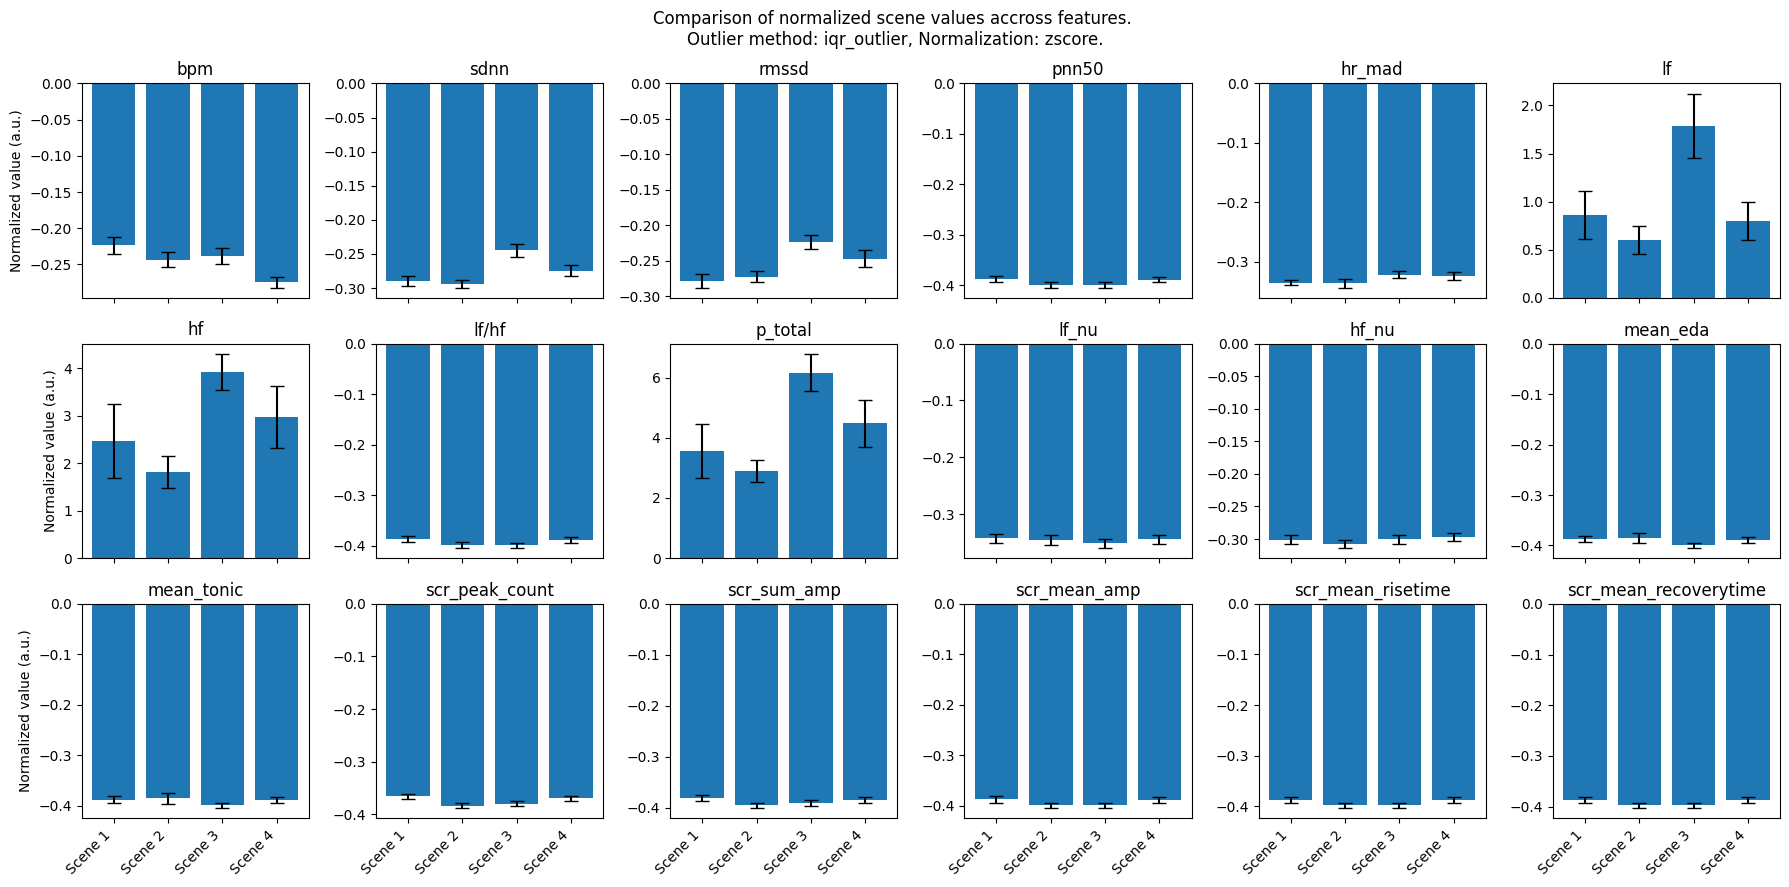

In [203]:
def compare_norm_scene(scenedata,savepath,show=True,save=True):
    features = scenedata[1].drop('Subject', axis=1).columns
    n_features = len(features)
    n_scenes = len(scenedata)

    ncols = 6
    nrows = ceil(n_features / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = np.array(axes).flatten() if isinstance(axes, np.ndarray) else np.array([axes])

    x_positions = list(range(n_scenes))
    x_labels = [f"Scene {i+1}" for i in range(n_scenes)]
    
    for idx, feature in enumerate(features):
        ax = axes[idx]
        values = []
        errors = []
        for key in scenedata.keys():
            value = scenedata[key][feature].mean()
            error = scenedata[key][feature].std() / np.sqrt(len(scenedata[key][feature]))
            values.append(value)
            errors.append(error)

        ax.bar(x_positions, values, yerr=errors, capsize=5)
        if idx // ncols == nrows - 1: 
                ax.set_xticks(x_positions)
                ax.set_xticklabels(x_labels, rotation=45, ha="right")
        else:
                ax.set_xticklabels([])

        if idx % ncols == 0: 
            ax.set_ylabel("Normalized value (a.u.)")
        else:
            ax.set_ylabel("")
        
        for j in range(n_features, len(axes)):
            axes[j].axis('off')

        ax.set_title(feature)
    
    fig.suptitle(f'Comparison of normalized scene values accross features. \nOutlier method: {outliermeth}, Normalization: {normtype}.')
    plt.tight_layout()
    
    if save:
        plt.savefig(
            os.path.join(savepath, f'feature_comparison_{outliermeth}_{normtype}.png'),
            dpi=300,
            bbox_inches='tight'
        )
    
    if show:
        plt.show()
    
    plt.close(fig)

compare_norm_scene(scenedata,savepath=outpath,show=True,save=True)

In [204]:
scenedata.keys()

dict_keys([1, 2, 3, 4])

In [205]:
feat_cols = [col for col in scenedata[1].columns if col not in ["Subject"]]

org_per_feat = {}
subjects = [1, 2, 3, 4, 6, 8, 9]
for feat in feat_cols:
    aggdata_np = np.zeros([len(subjects),5])
    for i in range(0,len(subjects)):
        scene1 = scenedata[1][scenedata[1]['Subject']==subjects[i]][feat].median()
        scene2 = scenedata[2][scenedata[2]['Subject']==subjects[i]][feat].median()
        scene3 = scenedata[3][scenedata[3]['Subject']==subjects[i]][feat].median()
        scene4 = scenedata[4][scenedata[4]['Subject']==subjects[i]][feat].median()

        aggdata_np[i,:] = np.array([subjects[i], scene1, scene2, scene3, scene4])

    columns = ['Subject', 'scene1', 'scene2', 'scene3', 'scene4']
    aggdata_df = pd.DataFrame(aggdata_np, columns=columns)

    org_per_feat.update({feat:aggdata_df})

org_per_feat['bpm']

,Subject,scene1,scene2,scene3,scene4
0,1.0,-0.178114,-0.166268,-0.166056,-0.298218
1,2.0,-0.248923,-0.249698,-0.236000,-0.259119
2,3.0,-0.154292,-0.286931,-0.261165,-0.304673
3,4.0,-0.116183,-0.249285,-0.242372,-0.256495
4,6.0,-0.351744,-0.341375,-0.350194,-0.353156
5,8.0,-0.290306,-0.280188,-0.286841,-0.294806
6,9.0,-0.135049,-0.130465,-0.137754,-0.164809


In [206]:
np.zeros([1,4])

array([[0., 0., 0., 0.]])

In [207]:
friedman_list = []
for feat in feat_cols:
    data = org_per_feat[feat].drop('Subject', axis=1)
    stat, p = friedmanchisquare(data['scene1'], data['scene2'], data['scene3'], data['scene4'])
    #stat, p = kruskal(data['scene1'], data['scene2'], data['scene3'], data['scene4'])
    friedman_list.append([stat, p])

friedman_df = pd.DataFrame(friedman_list, columns=['Statistic', 'p-value'], index=feat_cols)


In [208]:
friedman_df

,Statistic,p-value
bpm,12.771429,0.005158
sdnn,4.200000,0.240662
rmssd,4.200000,0.240662
pnn50,3.857143,0.277309
hr_mad,4.746269,0.191348
lf,4.371429,0.224049
hf,6.600000,0.085801
lf/hf,0.942857,0.815075
p_total,9.685714,0.021436
lf_nu,0.942857,0.815075


In [209]:
friedman_df[friedman_df['p-value']<0.05]

,Statistic,p-value
bpm,12.771429,0.005158
p_total,9.685714,0.021436
